# 02. Validation quantitative et analyses de scénarios du Counterparty Credit Risk Engine

Ce notebook complète le moteur de risque de contrepartie développé dans le premier notebook.

L'objectif est de vérifier la robustesse des principaux composants du modèle et d'analyser le comportement des indicateurs de risque sous différents scénarios de marché et de crédit.

Les analyses porteront notamment sur :

- la validation du modèle de Black-Scholes ;
- la validation et la convergence des simulations Monte Carlo ;
- la sensibilité des profils d'exposition à la volatilité ;
- la sensibilité de la CVA au risque de crédit de la contrepartie ;
- l'impact du Recovery Rate ;
- l'impact des paramètres de collatéralisation ;
- la comparaison entre exposition brute, netting et collateral ;
- des scénarios de stress combinés ;
- l'analyse des principales limites du modèle.

L'objectif final est de compléter le moteur de calcul par une démarche de validation quantitative, de stress testing et d'interprétation des résultats.

## 1. Préparation de l'environnement

Nous importons les bibliothèques nécessaires aux analyses quantitatives, aux simulations Monte Carlo et à la visualisation des résultats.

Les principales bibliothèques utilisées sont :

- **NumPy** pour les calculs numériques et les simulations ;
- **Pandas** pour la structuration et l'analyse des résultats ;
- **SciPy** pour les fonctions statistiques utilisées dans le pricing ;
- **Matplotlib** pour la visualisation des profils de risque et des analyses de sensibilité.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

In [2]:
# Paramètres généraux

S0 = 100.0
K = 100.0
r = 0.03
sigma = 0.20
T = 1.0

n_steps = 52
n_sims = 10_000

dt = T / n_steps

### Paramètres de référence

Nous utilisons les paramètres suivants comme scénario central :

- prix initial du sous-jacent : $S_0 = 100$ ;
- prix d'exercice : $K = 100$ ;
- taux sans risque : $r = 3\%$ ;
- volatilité : $\sigma = 20\%$ ;
- maturité : $T = 1$ an ;
- nombre de simulations Monte Carlo : $10\,000$ ;
- nombre de pas de temps : $52$.

Ces paramètres serviront de scénario de référence pour les différentes validations et analyses de sensibilité.

## 2. Validation du modèle de Black-Scholes

Avant d'utiliser le pricing des options dans le moteur d'exposition, nous vérifions la cohérence de l'implémentation du modèle de Black-Scholes.

Nous effectuerons trois vérifications principales :

1. la positivité des prix du Call et du Put ;
2. la relation de parité Call-Put ;
3. le comportement du prix de l'option lorsque certains paramètres de marché varient.

In [3]:
def black_scholes_call(S, K, r, sigma, T):

    if T <= 0:
        return np.maximum(S - K, 0.0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )


def black_scholes_put(S, K, r, sigma, T):

    if T <= 0:
        return np.maximum(K - S, 0.0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        K * np.exp(-r * T) * norm.cdf(-d2)
        - S * norm.cdf(-d1)
    )

### 2.1 Vérification de la parité Call-Put

Pour des options européennes de même strike et de même maturité, la relation de parité Call-Put est donnée par :

$$
C - P = S_0 - K e^{-rT}
$$

Cette relation constitue un test simple mais important de cohérence de notre implémentation.

In [4]:
call_price = black_scholes_call(
    S0, K, r, sigma, T
)

put_price = black_scholes_put(
    S0, K, r, sigma, T
)

lhs = call_price - put_price

rhs = (
    S0
    - K * np.exp(-r * T)
)

difference = lhs - rhs

print(f"Prix du Call : {call_price:.6f} €")
print(f"Prix du Put  : {put_price:.6f} €")

print()

print(f"C - P             : {lhs:.10f}")
print(f"S0 - K exp(-rT)   : {rhs:.10f}")
print(f"Écart              : {difference:.12f}")

Prix du Call : 9.413403 €
Prix du Put  : 6.457957 €

C - P             : 2.9554466451
S0 - K exp(-rT)   : 2.9554466451
Écart              : 0.000000000000


### Interprétation

L'écart entre les deux membres de la relation de parité Call-Put est pratiquement nul.

Cette vérification confirme la cohérence numérique des fonctions de valorisation du Call et du Put utilisées dans le moteur.

### 2.2 Sensibilité du prix de l'option au sous-jacent

Le prix d'une option dépend fortement du niveau du sous-jacent.

Pour analyser cette relation, nous faisons varier le prix du sous-jacent tout en conservant les autres paramètres constants.

Nous considérons une plage de valeurs comprises entre 60 € et 140 €.

L'objectif est d'observer le comportement du Call et du Put lorsque le prix du sous-jacent évolue.

In [5]:
S_values = np.linspace(60, 140, 200)

call_values = black_scholes_call(
    S_values,
    K,
    r,
    sigma,
    T
)

put_values = black_scholes_put(
    S_values,
    K,
    r,
    sigma,
    T
)

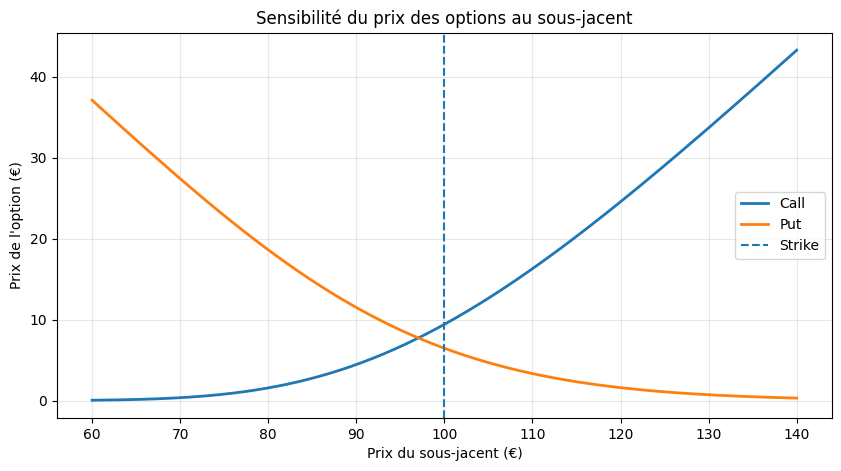

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(
    S_values,
    call_values,
    linewidth=2,
    label="Call"
)

plt.plot(
    S_values,
    put_values,
    linewidth=2,
    label="Put"
)

plt.axvline(
    K,
    linestyle="--",
    label="Strike"
)

plt.title(
    "Sensibilité du prix des options au sous-jacent"
)

plt.xlabel("Prix du sous-jacent (€)")
plt.ylabel("Prix de l'option (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interprétation

Lorsque le prix du sous-jacent augmente, la valeur du Call augmente tandis que la valeur du Put diminue.

Cette relation est cohérente avec la structure des payoffs des deux produits :

- un Call bénéficie d'une hausse du sous-jacent ;
- un Put bénéficie d'une baisse du sous-jacent.

Le strike constitue une zone importante dans l'évolution de la valeur des options, notamment lorsque l'option passe d'une situation hors de la monnaie à une situation dans la monnaie.

### 2.3 Sensibilité du prix de l'option à la volatilité

La volatilité représente l'incertitude sur les mouvements futurs du sous-jacent.

Toutes choses égales par ailleurs, une augmentation de la volatilité accroît généralement la valeur des options, car elle augmente la probabilité d'observer des mouvements favorables importants avant la maturité.

Nous faisons varier la volatilité entre 5 % et 60 % afin d'étudier son impact sur les prix du Call et du Put.

In [7]:
sigma_values = np.linspace(
    0.05,
    0.60,
    100
)

call_sigma = np.array([
    black_scholes_call(
        S0,
        K,
        r,
        sig,
        T
    )
    for sig in sigma_values
])

put_sigma = np.array([
    black_scholes_put(
        S0,
        K,
        r,
        sig,
        T
    )
    for sig in sigma_values
])

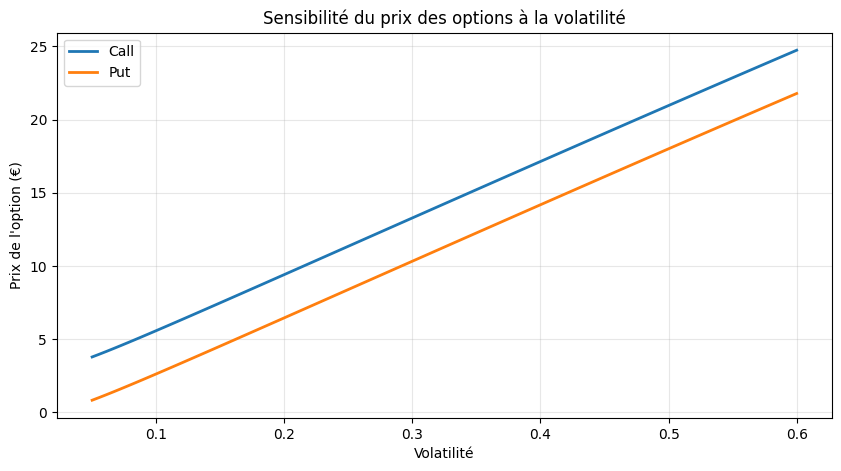

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    sigma_values,
    call_sigma,
    linewidth=2,
    label="Call"
)

plt.plot(
    sigma_values,
    put_sigma,
    linewidth=2,
    label="Put"
)

plt.title(
    "Sensibilité du prix des options à la volatilité"
)

plt.xlabel("Volatilité")
plt.ylabel("Prix de l'option (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interprétation

Le prix du Call et du Put augmente avec la volatilité.

Une volatilité plus élevée élargit la distribution des valeurs futures possibles du sous-jacent. Cette augmentation de l'incertitude accroît la valeur optionnelle, car le détenteur bénéficie des scénarios favorables tout en conservant un payoff limité à zéro dans les scénarios défavorables.

Cette propriété sera également importante dans l'analyse du risque de contrepartie, car une hausse de la volatilité peut modifier significativement les distributions de Mark-to-Market futurs et les niveaux d'exposition.

## 3. Validation du moteur Monte Carlo

Les simulations Monte Carlo constituent une composante centrale du moteur de risque de contrepartie.

Avant d'utiliser les résultats simulés pour calculer les expositions futures, il est nécessaire de vérifier que le moteur converge vers les propriétés théoriques attendues.

Nous étudierons notamment :

1. la convergence de l'espérance du prix futur du sous-jacent ;
2. l'effet du nombre de simulations sur l'erreur Monte Carlo ;
3. la stabilité des résultats lorsque le nombre de scénarios augmente.

### 3.1 Fonction de simulation

In [9]:
def simulate_terminal_prices(
    S0,
    r,
    sigma,
    T,
    n_sims,
    seed=42
):
    rng = np.random.default_rng(seed)

    Z = rng.standard_normal(
        n_sims
    )

    ST = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    return ST

### 3.2 Espérance théorique du prix à maturité

Sous la mesure risque-neutre, l'espérance théorique du prix du sous-jacent à maturité est :

$$
\mathbb{E}^{Q}[S_T] = S_0 e^{rT}
$$

La moyenne des simulations Monte Carlo doit converger vers cette valeur lorsque le nombre de scénarios augmente.

In [10]:
theoretical_mean = (
    S0 * np.exp(r * T)
)

print(
    f"Espérance théorique : "
    f"{theoretical_mean:.6f} €"
)

Espérance théorique : 103.045453 €


### 3.3 Étude de convergence

In [11]:
simulation_sizes = [
    100,
    500,
    1_000,
    5_000,
    10_000,
    50_000,
    100_000
]

convergence_results = []

In [12]:
for n in simulation_sizes:

    ST = simulate_terminal_prices(
        S0=S0,
        r=r,
        sigma=sigma,
        T=T,
        n_sims=n,
        seed=42
    )

    simulated_mean = np.mean(ST)

    absolute_error = abs(
        simulated_mean
        - theoretical_mean
    )

    relative_error = (
        absolute_error
        / theoretical_mean
    )

    convergence_results.append({
        "Nombre de simulations": n,
        "Moyenne simulée": simulated_mean,
        "Erreur absolue": absolute_error,
        "Erreur relative": relative_error
    })

In [13]:
convergence_df = pd.DataFrame(
    convergence_results
)

convergence_df

,Nombre de simulations,Moyenne simulée,Erreur absolue,Erreur relative
0,100,101.187017,1.858436,0.018035
1,500,102.621229,0.424224,0.004117
2,1000,102.400580,0.644873,0.006258
3,5000,102.634531,0.410923,0.003988
4,10000,102.860265,0.185188,0.001797
5,50000,103.045896,0.000443,0.000004
6,100000,102.974640,0.070813,0.000687


### 3.4 Visualiser la convergence

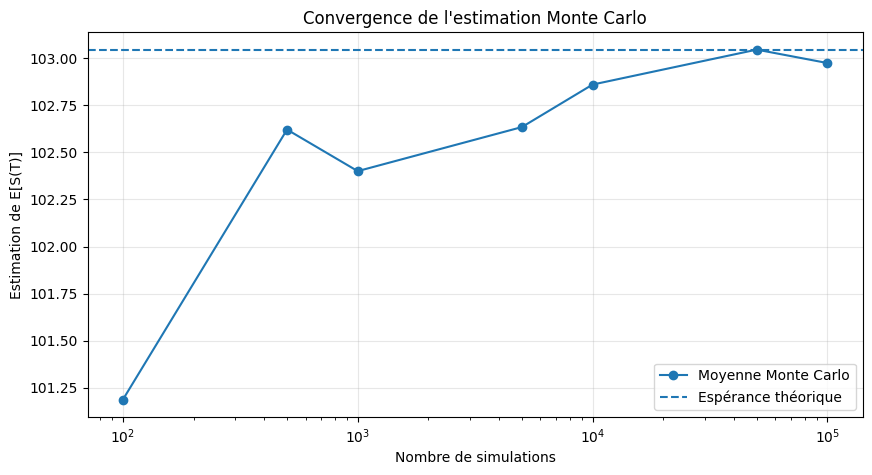

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    convergence_df[
        "Nombre de simulations"
    ],
    convergence_df[
        "Moyenne simulée"
    ],
    marker="o",
    label="Moyenne Monte Carlo"
)

plt.axhline(
    theoretical_mean,
    linestyle="--",
    label="Espérance théorique"
)

plt.xscale("log")

plt.title(
    "Convergence de l'estimation Monte Carlo"
)

plt.xlabel(
    "Nombre de simulations"
)

plt.ylabel(
    "Estimation de E[S(T)]"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

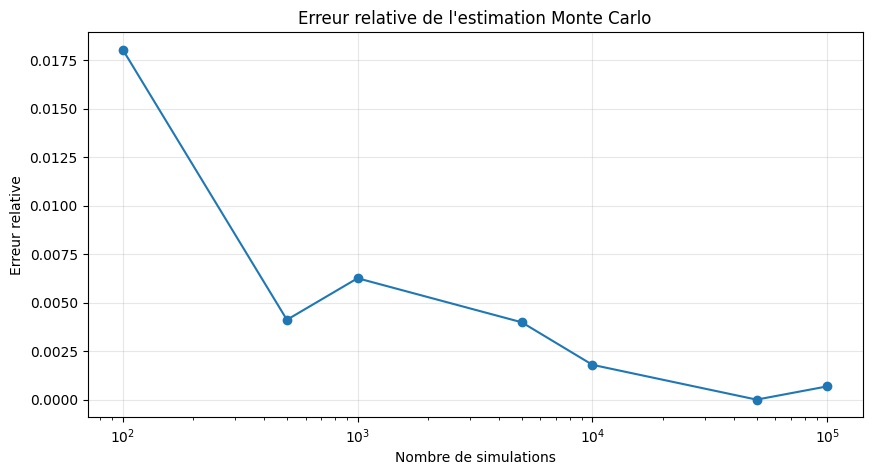

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    convergence_df[
        "Nombre de simulations"
    ],
    convergence_df[
        "Erreur relative"
    ],
    marker="o"
)

plt.xscale("log")

plt.title(
    "Erreur relative de l'estimation Monte Carlo"
)

plt.xlabel(
    "Nombre de simulations"
)

plt.ylabel(
    "Erreur relative"
)

plt.grid(alpha=0.3)

plt.show()

### Interprétation de la convergence

Lorsque le nombre de simulations augmente, l'estimation Monte Carlo de l'espérance du prix futur du sous-jacent devient globalement plus proche de la valeur théorique.

L'erreur Monte Carlo diminue progressivement avec l'augmentation du nombre de scénarios, même si cette diminution n'est pas parfaitement monotone en raison du caractère aléatoire de la simulation.

Cette analyse permet de vérifier que le moteur converge vers les propriétés théoriques attendues et justifie l'utilisation d'un nombre suffisamment élevé de simulations pour le calcul des expositions futures.

### 3.5 Convergence du pricing Monte Carlo vers Black-Scholes

Le modèle de Black-Scholes fournit une formule analytique pour valoriser un Call européen.

La méthode Monte Carlo permet également d'estimer cette valeur en simulant le prix du sous-jacent à maturité et en actualisant le payoff moyen du Call.

Sous la mesure risque-neutre, le prix du Call peut être écrit :

$$
C_0
=
e^{-rT}
\mathbb{E}^{Q}
\left[
\max(S_T-K,0)
\right]
$$

L'objectif de cette section est de vérifier que le prix obtenu par Monte Carlo converge vers le prix analytique de Black-Scholes lorsque le nombre de simulations augmente.

In [16]:
bs_call_price = black_scholes_call(
    S0,
    K,
    r,
    sigma,
    T
)

print(
    f"Prix Black-Scholes du Call : "
    f"{bs_call_price:.6f} €"
)

Prix Black-Scholes du Call : 9.413403 €


In [17]:
def monte_carlo_call_price(
    S0,
    K,
    r,
    sigma,
    T,
    n_sims,
    seed=42
):
    """
    Estime le prix d'un Call européen par Monte Carlo.
    """

    ST = simulate_terminal_prices(
        S0=S0,
        r=r,
        sigma=sigma,
        T=T,
        n_sims=n_sims,
        seed=seed
    )

    payoff = np.maximum(
        ST - K,
        0.0
    )

    price = (
        np.exp(-r * T)
        * np.mean(payoff)
    )

    return price

In [18]:
pricing_results = []

for n in simulation_sizes:

    mc_price = monte_carlo_call_price(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        n_sims=n,
        seed=42
    )

    absolute_error = abs(
        mc_price - bs_call_price
    )

    relative_error = (
        absolute_error / bs_call_price
    )

    pricing_results.append({
        "Nombre de simulations": n,
        "Prix Monte Carlo": mc_price,
        "Prix Black-Scholes": bs_call_price,
        "Erreur absolue": absolute_error,
        "Erreur relative": relative_error
    })

In [19]:
pricing_convergence_df = pd.DataFrame(
    pricing_results
)

pricing_convergence_df

,Nombre de simulations,Prix Monte Carlo,Prix Black-Scholes,Erreur absolue,Erreur relative
0,100,6.796331,9.413403,2.617073,0.278016
1,500,8.845828,9.413403,0.567575,0.060294
2,1000,8.881144,9.413403,0.532259,0.056543
3,5000,9.133390,9.413403,0.280013,0.029746
4,10000,9.313033,9.413403,0.100370,0.010662
5,50000,9.421739,9.413403,0.008335,0.000885
6,100000,9.387501,9.413403,0.025903,0.002752


### 3.6 Visualisation de la convergence du prix

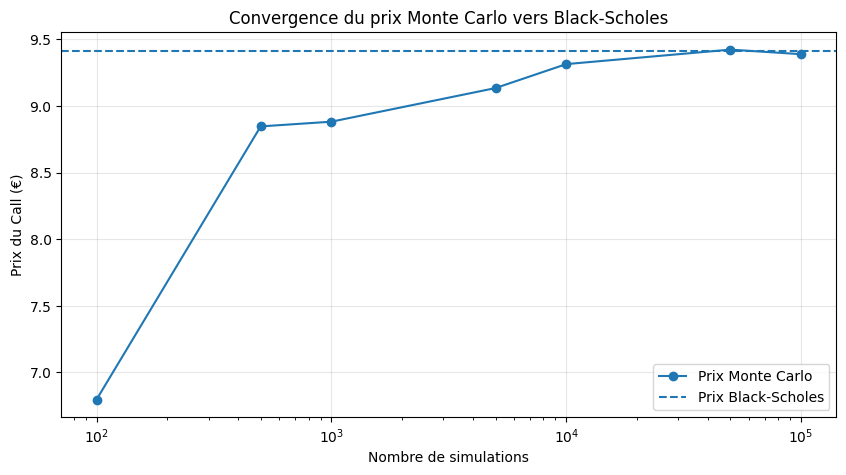

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    pricing_convergence_df[
        "Nombre de simulations"
    ],
    pricing_convergence_df[
        "Prix Monte Carlo"
    ],
    marker="o",
    label="Prix Monte Carlo"
)

plt.axhline(
    bs_call_price,
    linestyle="--",
    label="Prix Black-Scholes"
)

plt.xscale("log")

plt.title(
    "Convergence du prix Monte Carlo vers Black-Scholes"
)

plt.xlabel(
    "Nombre de simulations"
)

plt.ylabel(
    "Prix du Call (€)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

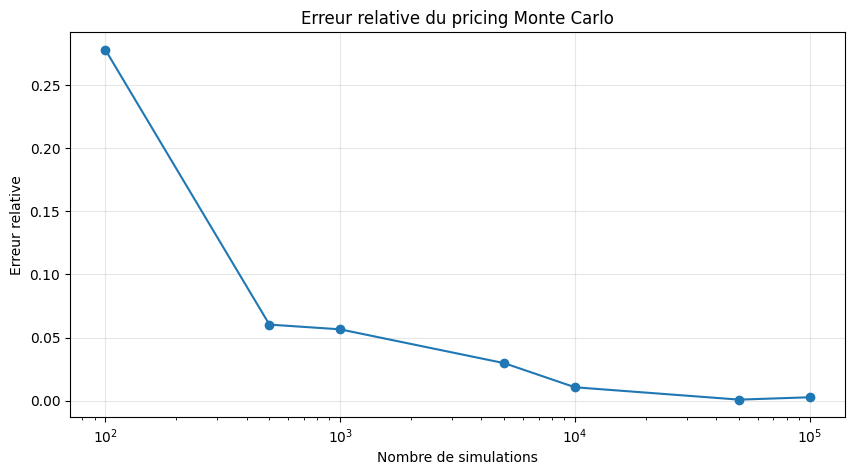

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    pricing_convergence_df[
        "Nombre de simulations"
    ],
    pricing_convergence_df[
        "Erreur relative"
    ],
    marker="o"
)

plt.xscale("log")

plt.title(
    "Erreur relative du pricing Monte Carlo"
)

plt.xlabel(
    "Nombre de simulations"
)

plt.ylabel(
    "Erreur relative"
)

plt.grid(alpha=0.3)

plt.show()

### Interprétation

Lorsque le nombre de simulations augmente, le prix obtenu par Monte Carlo se rapproche globalement du prix analytique fourni par le modèle de Black-Scholes.

Cette convergence confirme que le moteur de simulation est cohérent avec la valorisation risque-neutre utilisée pour les options européennes.

Comme pour l'estimation de l'espérance du sous-jacent, l'erreur ne diminue pas nécessairement de manière parfaitement monotone. Elle reste soumise à l'erreur d'échantillonnage propre aux méthodes Monte Carlo.

### 3.7 Erreur statistique et intervalle de confiance

Le prix Monte Carlo est obtenu à partir d'un échantillon fini de payoffs simulés.

Il possède donc une erreur statistique.

L'erreur standard de l'estimateur peut être approchée par :

$$
SE
=
e^{-rT}
\frac{
\sigma_{\text{payoff}}
}{
\sqrt{N}
}
$$

où :

- $N$ représente le nombre de simulations ;
- $\sigma_{\text{payoff}}$ représente l'écart-type des payoffs simulés.

Un intervalle de confiance approximatif à 95 % est alors :

$$
\hat{C}
\pm
1.96 \times SE
$$

In [22]:
n_validation = 100_000

ST = simulate_terminal_prices(
    S0=S0,
    r=r,
    sigma=sigma,
    T=T,
    n_sims=n_validation,
    seed=42
)

payoff = np.maximum(
    ST - K,
    0.0
)

discounted_payoff = (
    np.exp(-r * T)
    * payoff
)

mc_price = np.mean(
    discounted_payoff
)

standard_error = (
    np.std(
        discounted_payoff,
        ddof=1
    )
    / np.sqrt(n_validation)
)

ci_lower = (
    mc_price
    - 1.96 * standard_error
)

ci_upper = (
    mc_price
    + 1.96 * standard_error
)

print(
    f"Prix Monte Carlo : "
    f"{mc_price:.6f} €"
)

print(
    f"Erreur standard : "
    f"{standard_error:.6f} €"
)

print(
    f"IC 95% : "
    f"[{ci_lower:.6f} ; {ci_upper:.6f}]"
)

print(
    f"Prix Black-Scholes : "
    f"{bs_call_price:.6f} €"
)

Prix Monte Carlo : 9.387501 €
Erreur standard : 0.044852 €
IC 95% : [9.299592 ; 9.475410]
Prix Black-Scholes : 9.413403 €


### 3.8 Taux de convergence de la méthode Monte Carlo

La méthode Monte Carlo possède un taux de convergence théorique de l'ordre de :

$$
O\left(\frac{1}{\sqrt{N}}\right)
$$

Cela signifie que pour diviser approximativement l'erreur statistique par deux, il faut multiplier le nombre de simulations par quatre.

Cette propriété explique pourquoi les simulations Monte Carlo peuvent devenir coûteuses lorsque l'on cherche une très grande précision.

In [23]:
mc_sizes = np.array([
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
    500_000
])

standard_errors = []

for n in mc_sizes:

    ST = simulate_terminal_prices(
        S0=S0,
        r=r,
        sigma=sigma,
        T=T,
        n_sims=int(n),
        seed=42
    )

    payoff = np.maximum(
        ST - K,
        0.0
    )

    discounted_payoff = (
        np.exp(-r * T)
        * payoff
    )

    se = (
        np.std(
            discounted_payoff,
            ddof=1
        )
        / np.sqrt(n)
    )

    standard_errors.append(se)

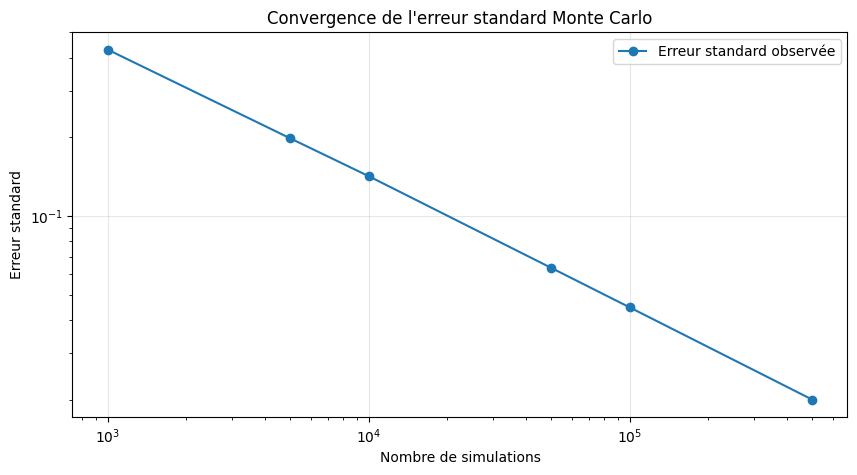

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    mc_sizes,
    standard_errors,
    marker="o",
    label="Erreur standard observée"
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Convergence de l'erreur standard Monte Carlo"
)

plt.xlabel(
    "Nombre de simulations"
)

plt.ylabel(
    "Erreur standard"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4. Validation des profils d'exposition

Après avoir validé le moteur de pricing et la convergence des simulations Monte Carlo, nous analysons maintenant la robustesse des métriques d'exposition utilisées pour mesurer le risque de contrepartie.

Les deux principaux indicateurs étudiés sont :

- l'Expected Exposure (EE), qui mesure l'exposition moyenne à une date future ;
- le Potential Future Exposure (PFE), qui mesure un quantile élevé de la distribution des expositions.

Nous étudierons notamment :

1. la construction des profils d'exposition ;
2. la sensibilité au niveau de confiance du PFE ;
3. la stabilité des métriques en fonction du nombre de simulations ;
4. la sensibilité des expositions à la volatilité du marché.

### 4.1 Construction des expositions futures

Pour chaque trajectoire Monte Carlo, le Call européen est revalorisé à chaque date future.

Le Mark-to-Market du produit dans le scénario $i$ à la date $t$ est noté :

$$
V_t^{(i)}
$$

L'exposition positive correspond à :

$$
E_t^{(i)} = \max(V_t^{(i)},0)
$$

À partir de cette distribution d'expositions, nous calculons ensuite l'Expected Exposure et différents niveaux de Potential Future Exposure.

In [25]:
def simulate_gbm_paths(
    S0,
    r,
    sigma,
    T,
    n_steps,
    n_sims,
    seed=42
):
    rng = np.random.default_rng(seed)

    dt = T / n_steps

    Z = rng.standard_normal(
        size=(n_sims, n_steps)
    )

    increments = (
        (r - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z
    )

    log_paths = np.cumsum(
        increments,
        axis=1
    )

    paths = np.empty(
        (n_sims, n_steps + 1)
    )

    paths[:, 0] = S0

    paths[:, 1:] = (
        S0 * np.exp(log_paths)
    )

    return paths

In [26]:
times = np.linspace(
    0,
    T,
    n_steps + 1
)

paths = simulate_gbm_paths(
    S0=S0,
    r=r,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_sims=n_sims,
    seed=42
)

print("Dimension :", paths.shape)

Dimension : (10000, 53)


### 4.2 Revalorisation du Call

In [27]:
future_mtm = np.empty_like(paths)

for j, t in enumerate(times):

    tau = T - t

    future_mtm[:, j] = black_scholes_call(
        paths[:, j],
        K,
        r,
        sigma,
        tau
    )

In [28]:
exposure = np.maximum(
    future_mtm,
    0.0
)

EE = np.mean(
    exposure,
    axis=0
)

PFE_95 = np.quantile(
    exposure,
    0.95,
    axis=0
)

PFE_99 = np.quantile(
    exposure,
    0.99,
    axis=0
)

In [29]:
print(f"EE initiale     : {EE[0]:.4f} €")
print(f"EE à maturité   : {EE[-1]:.4f} €")

print()

print(f"PFE 95% initial : {PFE_95[0]:.4f} €")
print(f"PFE 99% initial : {PFE_99[0]:.4f} €")

EE initiale     : 9.4134 €
EE à maturité   : 9.6327 €

PFE 95% initial : 9.4134 €
PFE 99% initial : 9.4134 €


### 4.3 Validation des niveaux de PFE

Le Potential Future Exposure dépend du niveau de confiance choisi.

Un quantile à 99 % doit être supérieur ou égal au quantile à 95 % pour une même distribution d'exposition :

$$
PFE_{99\%}(t)
\geq
PFE_{95\%}(t)
$$

Cette propriété constitue un contrôle simple de cohérence des métriques calculées.

In [30]:
pfe_test = np.all(
    PFE_99 >= PFE_95
)

print(
    "PFE 99% >= PFE 95% à toutes les dates :",
    pfe_test
)

PFE 99% >= PFE 95% à toutes les dates : True


In [31]:
pfe_gap = (
    PFE_99 - PFE_95
)

print(
    f"Écart moyen PFE99 - PFE95 : "
    f"{np.mean(pfe_gap):.4f} €"
)

print(
    f"Écart maximum : "
    f"{np.max(pfe_gap):.4f} €"
)

Écart moyen PFE99 - PFE95 : 11.8257 €
Écart maximum : 19.7618 €


### 4.4 Comparaison EE / PFE 95 / PFE 99

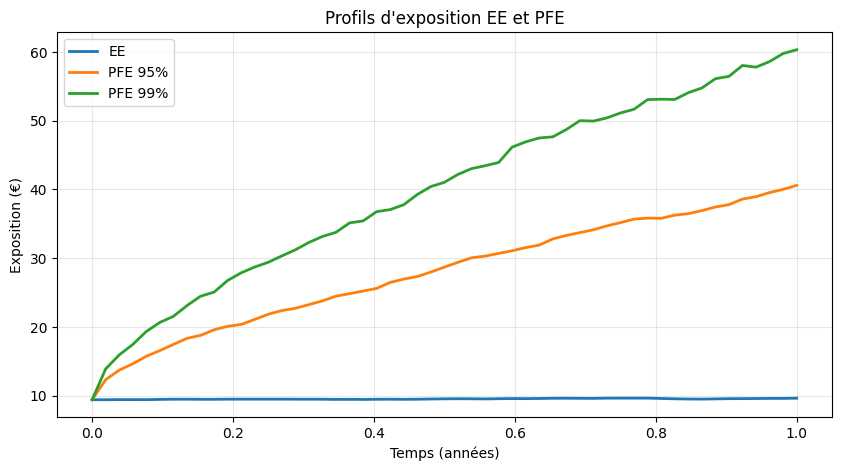

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    EE,
    linewidth=2,
    label="EE"
)

plt.plot(
    times,
    PFE_95,
    linewidth=2,
    label="PFE 95%"
)

plt.plot(
    times,
    PFE_99,
    linewidth=2,
    label="PFE 99%"
)

plt.title(
    "Profils d'exposition EE et PFE"
)

plt.xlabel("Temps (années)")
plt.ylabel("Exposition (€)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interprétation

L'Expected Exposure représente le niveau moyen d'exposition, tandis que les PFE représentent des niveaux plus élevés associés à la queue de la distribution.

Le PFE à 99 % est supérieur ou égal au PFE à 95 %, conformément à la définition des quantiles.

L'écart entre EE et PFE illustre l'importance de prendre en compte non seulement l'exposition moyenne, mais également les scénarios défavorables de forte exposition.

### 4.5 Sensibilité du PFE au niveau de confiance

Le niveau du PFE dépend directement du quantile retenu.

Nous calculons les profils correspondant aux niveaux de confiance suivants :

- 90 % ;
- 95 % ;
- 97,5 % ;
- 99 %.

Cette analyse permet d'observer comment la mesure de l'exposition potentielle augmente lorsque l'on considère des scénarios de plus en plus extrêmes.

In [33]:
confidence_levels = [
    0.90,
    0.95,
    0.975,
    0.99
]

PFE_profiles = {}

for confidence in confidence_levels:

    PFE_profiles[confidence] = np.quantile(
        exposure,
        confidence,
        axis=0
    )

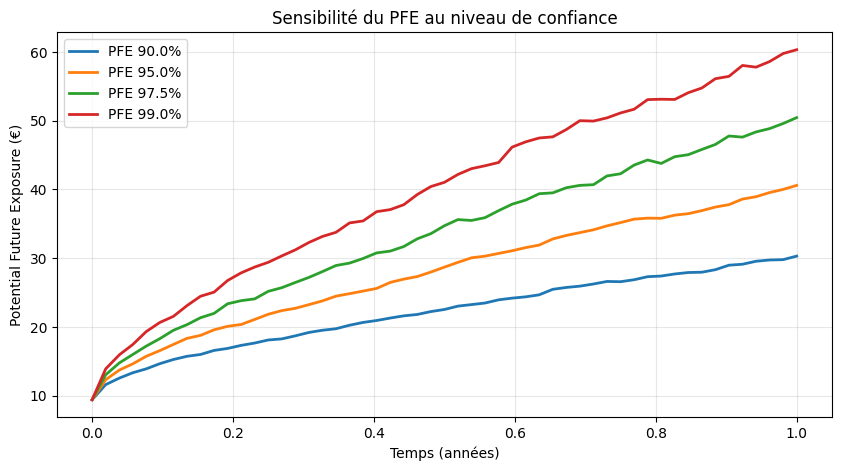

In [34]:
plt.figure(figsize=(10, 5))

for confidence, profile in PFE_profiles.items():

    plt.plot(
        times,
        profile,
        linewidth=2,
        label=f"PFE {confidence:.1%}"
    )

plt.title(
    "Sensibilité du PFE au niveau de confiance"
)

plt.xlabel("Temps (années)")
plt.ylabel("Potential Future Exposure (€)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4.6 Convergence des métriques d'exposition

Les indicateurs EE et PFE sont estimés à partir de distributions simulées et sont donc soumis à une erreur Monte Carlo.

Nous étudions leur stabilité lorsque le nombre de simulations augmente.

Cette analyse est particulièrement importante pour le PFE, car l'estimation d'un quantile élevé nécessite généralement davantage de simulations que l'estimation d'une moyenne.

In [35]:
mid_index = np.argmin(
    np.abs(times - 0.5)
)

print(
    f"Date sélectionnée : "
    f"{times[mid_index]:.4f} année"
)

Date sélectionnée : 0.5000 année


In [36]:
exposure_convergence = []

simulation_sizes_exposure = [
    500,
    1_000,
    5_000,
    10_000,
    25_000,
    50_000,
    100_000
]

for n in simulation_sizes_exposure:

    scenario_paths = simulate_gbm_paths(
        S0=S0,
        r=r,
        sigma=sigma,
        T=T,
        n_steps=n_steps,
        n_sims=n,
        seed=42
    )

    S_mid = scenario_paths[
        :,
        mid_index
    ]

    tau = (
        T - times[mid_index]
    )

    mtm_mid = black_scholes_call(
        S_mid,
        K,
        r,
        sigma,
        tau
    )

    exposure_mid = np.maximum(
        mtm_mid,
        0.0
    )

    ee_mid = np.mean(
        exposure_mid
    )

    pfe95_mid = np.quantile(
        exposure_mid,
        0.95
    )

    pfe99_mid = np.quantile(
        exposure_mid,
        0.99
    )

    exposure_convergence.append({
        "Nombre de simulations": n,
        "EE": ee_mid,
        "PFE 95%": pfe95_mid,
        "PFE 99%": pfe99_mid
    })

In [37]:
exposure_convergence_df = pd.DataFrame(
    exposure_convergence
)

exposure_convergence_df.round(4)

,Nombre de simulations,EE,PFE 95%,PFE 99%
0,500,9.8183,30.4891,41.0344
1,1000,9.6360,29.9897,41.0344
2,5000,9.5506,28.7588,41.1977
3,10000,9.5378,28.6998,41.0343
4,25000,9.5374,28.3258,40.8979
5,50000,9.5400,28.6111,40.9302
6,100000,9.5528,28.4244,41.0070


### 4.7 Visualisation de la convergence

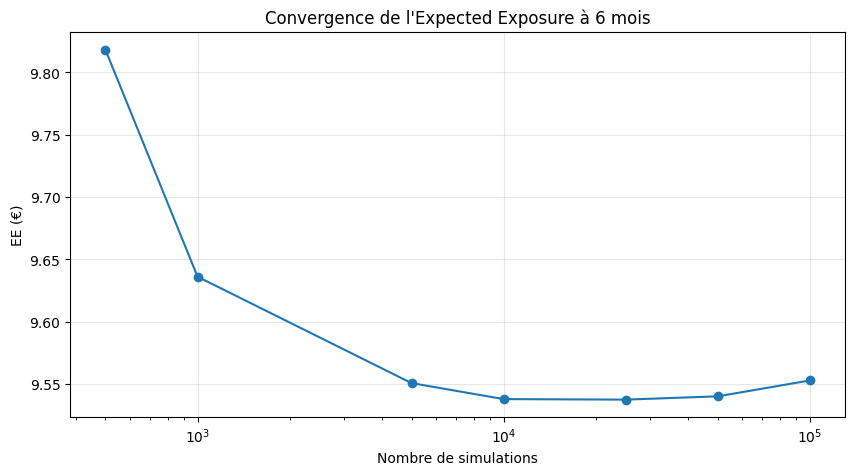

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    exposure_convergence_df[
        "Nombre de simulations"
    ],
    exposure_convergence_df["EE"],
    marker="o"
)

plt.xscale("log")

plt.title(
    "Convergence de l'Expected Exposure à 6 mois"
)

plt.xlabel("Nombre de simulations")
plt.ylabel("EE (€)")

plt.grid(alpha=0.3)

plt.show()

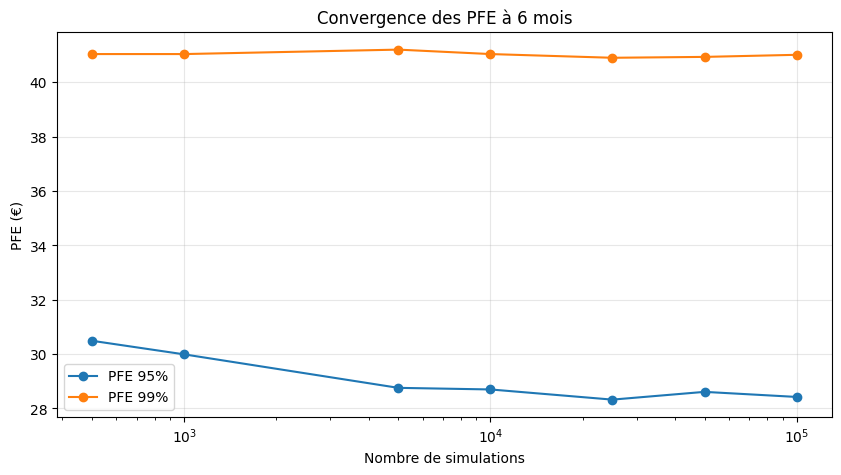

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    exposure_convergence_df[
        "Nombre de simulations"
    ],
    exposure_convergence_df[
        "PFE 95%"
    ],
    marker="o",
    label="PFE 95%"
)

plt.plot(
    exposure_convergence_df[
        "Nombre de simulations"
    ],
    exposure_convergence_df[
        "PFE 99%"
    ],
    marker="o",
    label="PFE 99%"
)

plt.xscale("log")

plt.title(
    "Convergence des PFE à 6 mois"
)

plt.xlabel("Nombre de simulations")
plt.ylabel("PFE (€)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interprétation de la convergence des expositions

Lorsque le nombre de simulations augmente, l'Expected Exposure et les Potential Future Exposures tendent à se stabiliser.

L'EE, qui correspond à une moyenne, présente généralement une meilleure stabilité statistique que les quantiles élevés.

Le PFE à 99 % peut présenter davantage de fluctuations que le PFE à 95 %, car son estimation repose sur un nombre plus faible d'observations situées dans la queue de la distribution.

Cette analyse souligne l'importance d'utiliser un nombre suffisamment élevé de scénarios Monte Carlo pour obtenir des estimations robustes des expositions extrêmes.

### 4.8 Stabilité des métriques entre plusieurs simulations

La convergence peut également être étudiée en répétant le calcul avec plusieurs graines aléatoires.

Si le nombre de simulations est suffisant, les valeurs obtenues pour l'EE et le PFE devraient rester relativement proches d'une simulation à l'autre.

Nous testons cette stabilité avec 10 000 scénarios Monte Carlo.

In [40]:
seeds = [
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100
]

stability_results = []

for seed in seeds:

    scenario_paths = simulate_gbm_paths(
        S0=S0,
        r=r,
        sigma=sigma,
        T=T,
        n_steps=n_steps,
        n_sims=10_000,
        seed=seed
    )

    S_mid = scenario_paths[
        :,
        mid_index
    ]

    tau = T - times[mid_index]

    mtm_mid = black_scholes_call(
        S_mid,
        K,
        r,
        sigma,
        tau
    )

    exposure_mid = np.maximum(
        mtm_mid,
        0.0
    )

    stability_results.append({
        "Seed": seed,
        "EE": np.mean(exposure_mid),
        "PFE 95%": np.quantile(
            exposure_mid,
            0.95
        ),
        "PFE 99%": np.quantile(
            exposure_mid,
            0.99
        )
    })

In [41]:
stability_df = pd.DataFrame(
    stability_results
)

stability_df.round(4)

,Seed,EE,PFE 95%,PFE 99%
0,10,9.5143,28.2115,40.8933
1,20,9.5230,28.4341,41.4869
2,30,9.5193,28.0544,40.6365
3,40,9.5362,28.3908,41.5419
4,50,9.6739,28.7281,42.2317
5,60,9.5466,28.1310,41.4576
6,70,9.4361,28.3896,41.8680
7,80,9.6114,29.1816,42.3469
8,90,9.3827,27.7161,40.0057
9,100,9.4279,28.5193,39.4160


In [42]:
stability_summary = pd.DataFrame({
    "Moyenne": stability_df[
        ["EE", "PFE 95%", "PFE 99%"]
    ].mean(),

    "Écart-type": stability_df[
        ["EE", "PFE 95%", "PFE 99%"]
    ].std(),

    "Coefficient de variation": (
        stability_df[
            ["EE", "PFE 95%", "PFE 99%"]
        ].std()
        /
        stability_df[
            ["EE", "PFE 95%", "PFE 99%"]
        ].mean()
    )
})

stability_summary.round(6)

,Moyenne,Écart-type,Coefficient de variation
EE,9.517142,0.086496,0.009088
PFE 95%,28.375653,0.397669,0.014014
PFE 99%,41.188441,0.949332,0.023048


## 5. Validation et sensibilité de la CVA

La Credit Valuation Adjustment (CVA) dépend principalement de trois composantes :

- l'exposition future attendue ;
- la probabilité de défaut de la contrepartie ;
- la Loss Given Default (LGD).

Dans une approche discrète simplifiée :

$$
CVA
=
LGD
\sum_{i=1}^{M}
DF(t_i)
\times
EE(t_i)
\times
\Delta PD_i
$$

L'objectif de cette section est de vérifier que la CVA réagit de manière cohérente lorsque les paramètres de risque de crédit ou d'exposition varient.

Nous étudierons notamment :

1. la sensibilité au hazard rate ;
2. la sensibilité au Recovery Rate ;
3. la sensibilité au niveau d'exposition ;
4. l'impact du netting et du collateral ;
5. des scénarios combinant risque de marché et risque de crédit.

### 5.1 Fonction générique de calcul de CVA

In [43]:
def compute_cva(
    EE,
    times,
    r,
    hazard_rate,
    recovery_rate
):
    """
    Calcule une CVA discrète à partir d'un profil d'Expected Exposure.
    """

    # Probabilité de survie
    survival_prob = np.exp(
        -hazard_rate * times
    )

    # Probabilités marginales de défaut
    marginal_pd = (
        survival_prob[:-1]
        - survival_prob[1:]
    )

    # Facteurs d'actualisation
    discount_factors = np.exp(
        -r * times
    )

    # Loss Given Default
    LGD = 1 - recovery_rate

    # Calcul de la CVA
    cva = np.sum(
        LGD
        * discount_factors[1:]
        * EE[1:]
        * marginal_pd
    )

    return cva

In [44]:
hazard_rate_ref = 0.02
recovery_rate_ref = 0.40

cva_reference = compute_cva(
    EE=EE,
    times=times,
    r=r,
    hazard_rate=hazard_rate_ref,
    recovery_rate=recovery_rate_ref
)

print(
    f"CVA de référence : "
    f"{cva_reference:.6f} €"
)

CVA de référence : 0.111477 €


### 5.2 Sensibilité de la CVA au Hazard Rate

Le hazard rate représente l'intensité de défaut de la contrepartie.

Toutes choses égales par ailleurs, une augmentation du hazard rate augmente la probabilité de défaut et doit donc entraîner une augmentation de la CVA.

Nous faisons varier le hazard rate entre 0,5 % et 10 %.

In [45]:
hazard_values = np.linspace(
    0.005,
    0.10,
    50
)

cva_hazard = []

for hazard in hazard_values:

    cva_value = compute_cva(
        EE=EE,
        times=times,
        r=r,
        hazard_rate=hazard,
        recovery_rate=recovery_rate_ref
    )

    cva_hazard.append(
        cva_value
    )

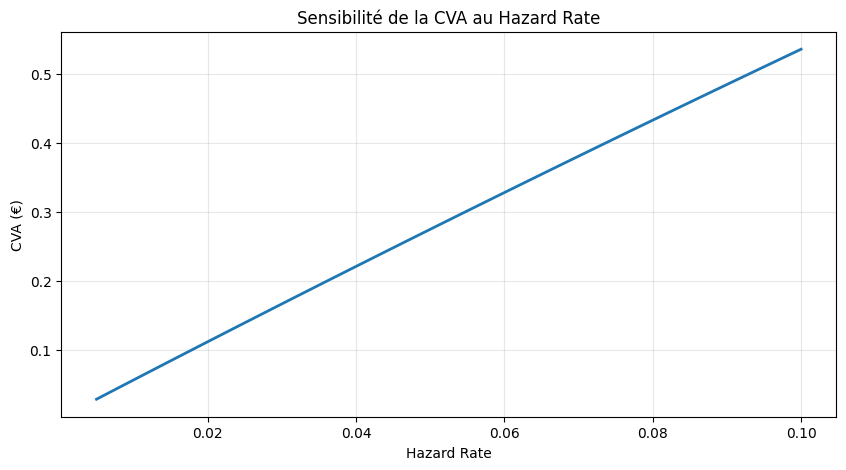

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    hazard_values,
    cva_hazard,
    linewidth=2
)

plt.title(
    "Sensibilité de la CVA au Hazard Rate"
)

plt.xlabel("Hazard Rate")
plt.ylabel("CVA (€)")
plt.grid(alpha=0.3)

plt.show()

### Interprétation

La CVA augmente avec le hazard rate.

Cette relation est cohérente avec la structure du modèle : une détérioration de la qualité de crédit de la contrepartie augmente la probabilité de défaut, ce qui accroît la perte attendue associée à l'exposition future.

### 5.3 Validation de la monotonie

In [47]:
hazard_monotonicity = np.all(
    np.diff(cva_hazard) >= 0
)

print(
    "CVA croissante avec le Hazard Rate :",
    hazard_monotonicity
)

CVA croissante avec le Hazard Rate : True


### 5.4 Sensibilité de la CVA au Recovery Rate

Le Recovery Rate représente la proportion de l'exposition récupérée après le défaut de la contrepartie.

La Loss Given Default est définie par :

$$
LGD = 1 - R
$$

Par conséquent, une augmentation du Recovery Rate réduit la perte potentielle en cas de défaut et doit entraîner une diminution de la CVA.

In [48]:
recovery_values = np.linspace(
    0.10,
    0.80,
    50
)

cva_recovery = []

for recovery in recovery_values:

    cva_value = compute_cva(
        EE=EE,
        times=times,
        r=r,
        hazard_rate=hazard_rate_ref,
        recovery_rate=recovery
    )

    cva_recovery.append(
        cva_value
    )

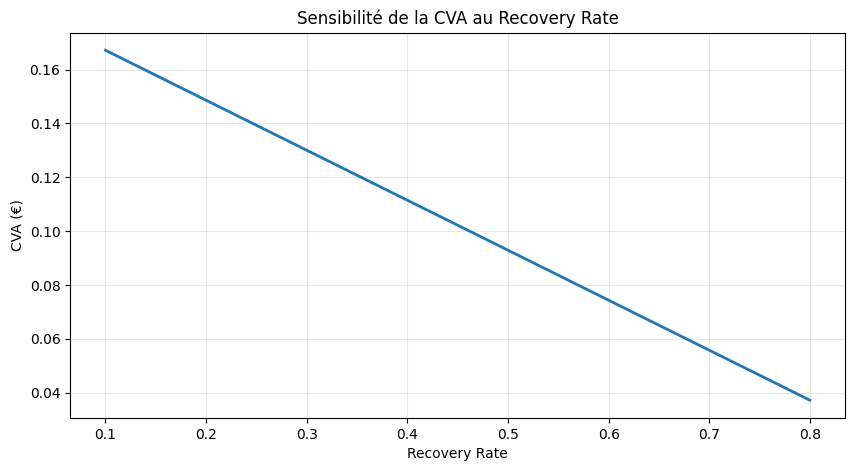

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(
    recovery_values,
    cva_recovery,
    linewidth=2
)

plt.title(
    "Sensibilité de la CVA au Recovery Rate"
)

plt.xlabel("Recovery Rate")
plt.ylabel("CVA (€)")
plt.grid(alpha=0.3)

plt.show()

In [50]:
recovery_monotonicity = np.all(
    np.diff(cva_recovery) <= 0
)

print(
    "CVA décroissante avec le Recovery Rate :",
    recovery_monotonicity
)

CVA décroissante avec le Recovery Rate : True


### 5.5 Sensibilité de la CVA au niveau d'exposition

La CVA est directement liée au profil d'Expected Exposure.

Afin de vérifier cette relation, nous multiplions le profil d'exposition de référence par différents facteurs.

Nous considérons notamment :

- 50 % de l'exposition initiale ;
- 100 % de l'exposition initiale ;
- 150 % ;
- 200 %.

Toutes choses égales par ailleurs, la CVA devrait évoluer proportionnellement au niveau d'exposition.

In [51]:
exposure_multipliers = [
    0.5,
    1.0,
    1.5,
    2.0
]

exposure_sensitivity = []

for multiplier in exposure_multipliers:

    stressed_EE = (
        EE * multiplier
    )

    stressed_cva = compute_cva(
        EE=stressed_EE,
        times=times,
        r=r,
        hazard_rate=hazard_rate_ref,
        recovery_rate=recovery_rate_ref
    )

    exposure_sensitivity.append({
        "Multiplicateur": multiplier,
        "CVA": stressed_cva
    })

In [52]:
exposure_sensitivity_df = pd.DataFrame(
    exposure_sensitivity
)

exposure_sensitivity_df

,Multiplicateur,CVA
0,0.5,0.055739
1,1.0,0.111477
2,1.5,0.167216
3,2.0,0.222954


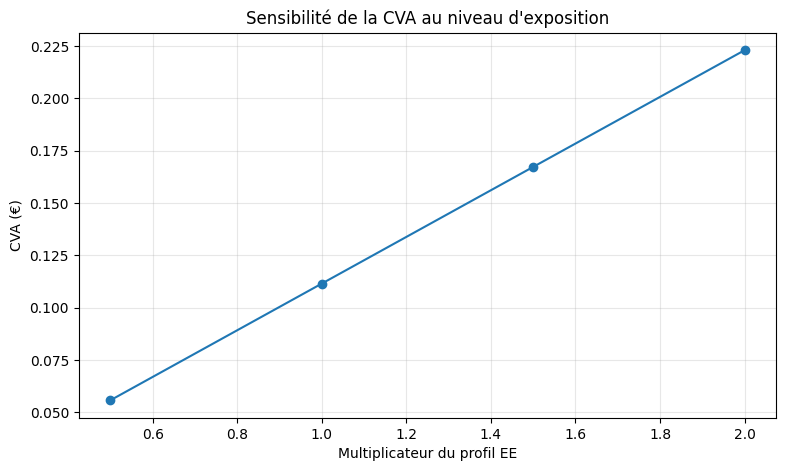

In [53]:
plt.figure(figsize=(9, 5))

plt.plot(
    exposure_sensitivity_df[
        "Multiplicateur"
    ],
    exposure_sensitivity_df[
        "CVA"
    ],
    marker="o"
)

plt.title(
    "Sensibilité de la CVA au niveau d'exposition"
)

plt.xlabel(
    "Multiplicateur du profil EE"
)

plt.ylabel(
    "CVA (€)"
)

plt.grid(alpha=0.3)

plt.show()

### 5.6 Scénarios combinés de risque de marché et de crédit

Le risque de contrepartie résulte de l'interaction entre les mouvements de marché et la qualité de crédit de la contrepartie.

Nous construisons plusieurs scénarios combinant :

- différents niveaux d'exposition ;
- différents hazard rates ;
- différents Recovery Rates.

Ces scénarios permettent d'analyser la CVA dans des conditions plus ou moins défavorables.

In [54]:
combined_scenarios = {
    "Optimiste": {
        "exposure_multiplier": 0.80,
        "hazard_rate": 0.01,
        "recovery_rate": 0.50
    },

    "Central": {
        "exposure_multiplier": 1.00,
        "hazard_rate": 0.02,
        "recovery_rate": 0.40
    },

    "Dégradé": {
        "exposure_multiplier": 1.30,
        "hazard_rate": 0.04,
        "recovery_rate": 0.35
    },

    "Stress sévère": {
        "exposure_multiplier": 1.70,
        "hazard_rate": 0.08,
        "recovery_rate": 0.25
    }
}

In [55]:
combined_results = []

for scenario_name, params in combined_scenarios.items():

    stressed_EE = (
        EE
        * params[
            "exposure_multiplier"
        ]
    )

    scenario_cva = compute_cva(
        EE=stressed_EE,
        times=times,
        r=r,
        hazard_rate=params[
            "hazard_rate"
        ],
        recovery_rate=params[
            "recovery_rate"
        ]
    )

    combined_results.append({
        "Scénario": scenario_name,
        "Multiplicateur EE":
            params[
                "exposure_multiplier"
            ],
        "Hazard Rate":
            params[
                "hazard_rate"
            ],
        "Recovery Rate":
            params[
                "recovery_rate"
            ],
        "CVA":
            scenario_cva
    })

In [56]:
combined_df = pd.DataFrame(
    combined_results
)

combined_df

,Scénario,Multiplicateur EE,Hazard Rate,Recovery Rate,CVA
0,Optimiste,0.8,0.01,0.50,0.037345
1,Central,1.0,0.02,0.40,0.111477
2,Dégradé,1.3,0.04,0.35,0.310891
3,Stress sévère,1.7,0.08,0.25,0.919830


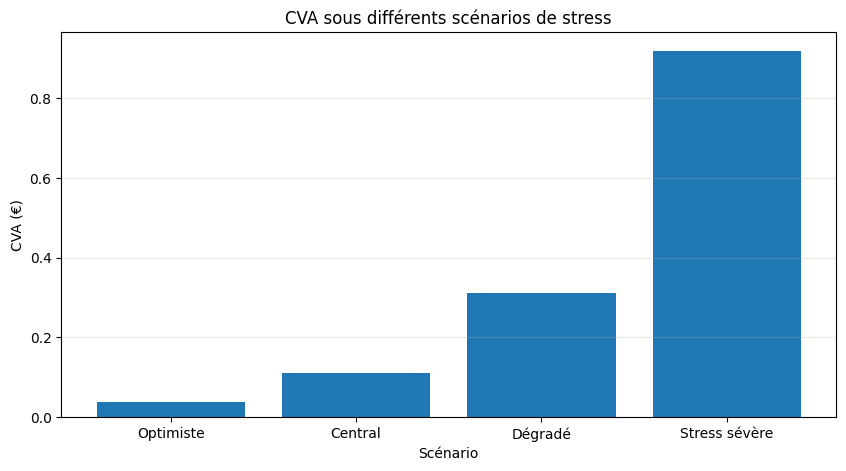

In [57]:
plt.figure(figsize=(10, 5))

plt.bar(
    combined_df["Scénario"],
    combined_df["CVA"]
)

plt.title(
    "CVA sous différents scénarios de stress"
)

plt.xlabel("Scénario")
plt.ylabel("CVA (€)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interprétation des scénarios combinés

Les résultats montrent que la CVA augmente fortement lorsque plusieurs facteurs de risque se détériorent simultanément.

Une augmentation des expositions futures combinée à une dégradation de la qualité de crédit et à une diminution du Recovery Rate conduit à une augmentation significative de la perte attendue liée au risque de contrepartie.

Cette analyse illustre l'importance des stress tests combinés, car l'impact conjoint de plusieurs facteurs peut être beaucoup plus important qu'une variation isolée d'un seul paramètre.

## 6. Validation des techniques de réduction du risque

Le netting et la collatéralisation sont deux mécanismes importants de réduction du risque de contrepartie.

Le **netting** permet de compenser les valeurs positives et négatives des transactions appartenant au même ensemble de compensation.

Le **collateral** permet ensuite de couvrir une partie de l'exposition nette en transférant des garanties entre les contreparties.

L'objectif de cette section est de vérifier quantitativement que ces mécanismes réduisent bien les principaux indicateurs de risque de contrepartie.

Nous comparerons :

1. l'exposition brute sans netting ;
2. l'exposition après netting ;
3. l'exposition après netting et collatéralisation.

### 6.1 Portefeuille de référence

Nous considérons un portefeuille composé de plusieurs options européennes longues et courtes.

Cette structure permet de générer des Mark-to-Market positifs et négatifs selon les scénarios de marché, ce qui rend possible l'analyse du bénéfice du netting.

In [58]:
portfolio = pd.DataFrame({
    "transaction": ["T1", "T2", "T3", "T4"],
    "type": ["call", "call", "put", "put"],
    "strike": [90, 110, 95, 105],
    "quantity": [100, -80, 60, -50]
})

portfolio

,transaction,type,strike,quantity
0,T1,call,90,100
1,T2,call,110,-80
2,T3,put,95,60
3,T4,put,105,-50


In [59]:
def black_scholes_put_vectorized(
    S,
    K,
    r,
    sigma,
    tau
):
    if tau <= 0:
        return np.maximum(
            K - S,
            0.0
        )

    d1 = (
        np.log(S / K)
        + (
            r
            + 0.5 * sigma**2
        ) * tau
    ) / (
        sigma * np.sqrt(tau)
    )

    d2 = (
        d1
        - sigma * np.sqrt(tau)
    )

    return (
        K
        * np.exp(-r * tau)
        * norm.cdf(-d2)
        - S * norm.cdf(-d1)
    )

### 6.2 Revalorisation du portefeuille

In [60]:
transaction_mtms = {}

for _, trade in portfolio.iterrows():

    trade_mtm = np.empty_like(paths)

    for j, t in enumerate(times):

        tau = T - t

        if trade["type"] == "call":

            unit_value = black_scholes_call(
                paths[:, j],
                trade["strike"],
                r,
                sigma,
                tau
            )

        else:

            unit_value = black_scholes_put_vectorized(
                paths[:, j],
                trade["strike"],
                r,
                sigma,
                tau
            )

        trade_mtm[:, j] = (
            trade["quantity"]
            * unit_value
        )

    transaction_mtms[
        trade["transaction"]
    ] = trade_mtm

In [61]:
for name, mtm in transaction_mtms.items():
    print(
        name,
        mtm.shape,
        f"MtM initial = {mtm[0,0]:,.2f} €"
    )

T1 (10000, 53) MtM initial = 1,542.92 €
T2 (10000, 53) MtM initial = -423.47 €
T3 (10000, 53) MtM initial = 262.32 €
T4 (10000, 53) MtM initial = -451.24 €


### 6.3 Exposition brute

Sans netting, chaque transaction positive contribue séparément à l'exposition.

L'exposition brute est donc définie par :

$$
E_t^{Gross}
=
\sum_k
\max(V_t^{(k)},0)
$$

In [62]:
gross_exposure = np.zeros_like(paths)

for mtm in transaction_mtms.values():

    gross_exposure += np.maximum(
        mtm,
        0.0
    )

In [63]:
EE_gross = np.mean(
    gross_exposure,
    axis=0
)

EPE_gross = np.mean(
    EE_gross
)

### 6.4 Exposition après netting

Avec un accord de netting, les Mark-to-Market des différentes transactions peuvent être compensés avant le calcul de l'exposition.

Le Mark-to-Market net du portefeuille est :

$$
V_t^{Net}
=
\sum_k V_t^{(k)}
$$

L'exposition nette est ensuite :

$$
E_t^{Net}
=
\max(V_t^{Net},0)
$$

In [64]:
portfolio_mtm = np.zeros_like(paths)

for mtm in transaction_mtms.values():
    portfolio_mtm += mtm


net_exposure = np.maximum(
    portfolio_mtm,
    0.0
)

EE_net = np.mean(
    net_exposure,
    axis=0
)

EPE_net = np.mean(
    EE_net
)

In [65]:
netting_test = np.all(
    EE_net <= EE_gross + 1e-10
)

print(
    "EE Netting <= EE Gross :",
    netting_test
)

EE Netting <= EE Gross : True


### 6.5 Exposition après collatéralisation

Nous introduisons maintenant un mécanisme simplifié de collatéralisation.

Le collatéral est appelé lorsque le Mark-to-Market net dépasse un seuil appelé **Threshold**.

Dans notre approche :

$$
C_t
=
\max(V_t^{Net}-H,0)
$$

où $H$ représente le Threshold.

L'exposition résiduelle devient :

$$
E_t^{Coll}
=
\max(V_t^{Net}-C_t,0)
$$

In [66]:
threshold = 500.0

collateral = np.maximum(
    portfolio_mtm - threshold,
    0.0
)

collateralized_exposure = np.maximum(
    portfolio_mtm - collateral,
    0.0
)

EE_collateral = np.mean(
    collateralized_exposure,
    axis=0
)

EPE_collateral = np.mean(
    EE_collateral
)

In [67]:
collateral_test = np.all(
    EE_collateral
    <= EE_net + 1e-10
)

print(
    "EE Collateral <= EE Netting :",
    collateral_test
)

EE Collateral <= EE Netting : True


### 6.6 Comparaison des profils EE

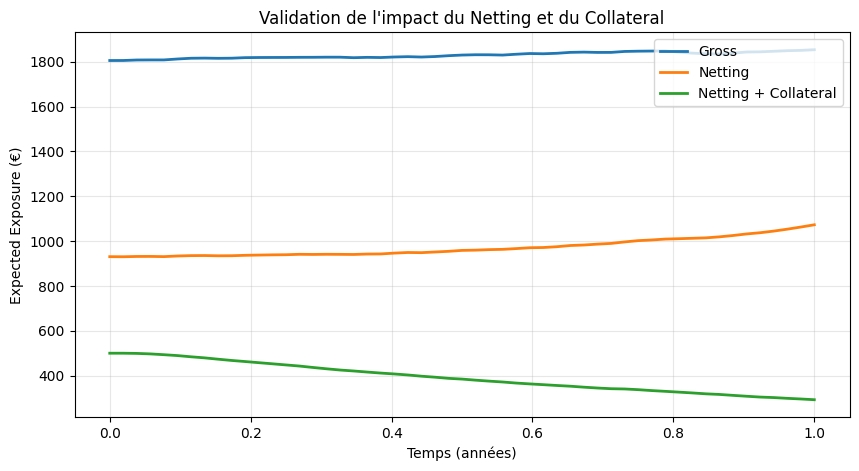

In [68]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    EE_gross,
    linewidth=2,
    label="Gross"
)

plt.plot(
    times,
    EE_net,
    linewidth=2,
    label="Netting"
)

plt.plot(
    times,
    EE_collateral,
    linewidth=2,
    label="Netting + Collateral"
)

plt.title(
    "Validation de l'impact du Netting et du Collateral"
)

plt.xlabel("Temps (années)")
plt.ylabel("Expected Exposure (€)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 6.7 Comparaison des EPE

In [69]:
epe_comparison = pd.DataFrame({
    "Configuration": [
        "Gross",
        "Netting",
        "Netting + Collateral"
    ],

    "EPE": [
        EPE_gross,
        EPE_net,
        EPE_collateral
    ]
})

epe_comparison.round(2)

,Configuration,EPE
0,Gross,1828.80
1,Netting,971.33
2,Netting + Collateral,391.74


In [70]:
netting_reduction = (
    EPE_gross - EPE_net
) / EPE_gross

collateral_reduction = (
    EPE_net - EPE_collateral
) / EPE_net

total_reduction = (
    EPE_gross - EPE_collateral
) / EPE_gross

print(
    f"Réduction EPE par netting : "
    f"{netting_reduction:.2%}"
)

print(
    f"Réduction additionnelle par collateral : "
    f"{collateral_reduction:.2%}"
)

print(
    f"Réduction totale : "
    f"{total_reduction:.2%}"
)

Réduction EPE par netting : 46.89%
Réduction additionnelle par collateral : 59.67%
Réduction totale : 78.58%


### 6.8 Validation sur le PFE

In [71]:
PFE95_gross = np.quantile(
    gross_exposure,
    0.95,
    axis=0
)

PFE95_net = np.quantile(
    net_exposure,
    0.95,
    axis=0
)

PFE95_collateral = np.quantile(
    collateralized_exposure,
    0.95,
    axis=0
)

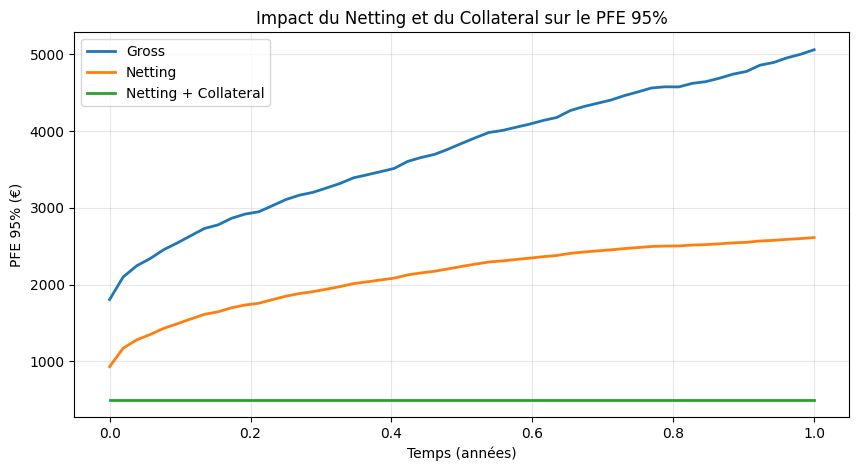

In [72]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    PFE95_gross,
    linewidth=2,
    label="Gross"
)

plt.plot(
    times,
    PFE95_net,
    linewidth=2,
    label="Netting"
)

plt.plot(
    times,
    PFE95_collateral,
    linewidth=2,
    label="Netting + Collateral"
)

plt.title(
    "Impact du Netting et du Collateral sur le PFE 95%"
)

plt.xlabel("Temps (années)")
plt.ylabel("PFE 95% (€)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 6.9 Impact sur la CVA

In [73]:
CVA_gross = compute_cva(
    EE=EE_gross,
    times=times,
    r=r,
    hazard_rate=hazard_rate_ref,
    recovery_rate=recovery_rate_ref
)

CVA_net = compute_cva(
    EE=EE_net,
    times=times,
    r=r,
    hazard_rate=hazard_rate_ref,
    recovery_rate=recovery_rate_ref
)

CVA_collateral = compute_cva(
    EE=EE_collateral,
    times=times,
    r=r,
    hazard_rate=hazard_rate_ref,
    recovery_rate=recovery_rate_ref
)

In [74]:
risk_mitigation_summary = pd.DataFrame({
    "Configuration": [
        "Gross",
        "Netting",
        "Netting + Collateral"
    ],

    "EPE": [
        EPE_gross,
        EPE_net,
        EPE_collateral
    ],

    "Max PFE 95%": [
        np.max(PFE95_gross),
        np.max(PFE95_net),
        np.max(PFE95_collateral)
    ],

    "CVA": [
        CVA_gross,
        CVA_net,
        CVA_collateral
    ]
})

risk_mitigation_summary.round(2)

,Configuration,EPE,Max PFE 95%,CVA
0,Gross,1828.80,5059.0,21.40
1,Netting,971.33,2611.8,11.37
2,Netting + Collateral,391.74,500.0,4.57


In [75]:
cva_validation = (
    CVA_collateral
    <= CVA_net
    <= CVA_gross
)

print(
    "Hiérarchie CVA respectée :",
    cva_validation
)

Hiérarchie CVA respectée : True


### Conclusion

Les tests confirment que les mécanismes de réduction du risque se comportent de manière cohérente dans notre moteur.

Le netting réduit l'exposition en permettant la compensation des Mark-to-Market positifs et négatifs au sein du portefeuille.

La collatéralisation réduit ensuite l'exposition résiduelle en couvrant une partie du Mark-to-Market positif.

Les résultats vérifient ainsi les relations attendues :

$$
EE_{Collateral}
\leq
EE_{Netting}
\leq
EE_{Gross}
$$

et :

$$
CVA_{Collateral}
\leq
CVA_{Netting}
\leq
CVA_{Gross}
$$

Cette validation confirme que les mécanismes de réduction du risque sont correctement pris en compte dans le moteur simplifié.

## 7. Stress Tests combinés

Les analyses précédentes ont étudié séparément l'impact de plusieurs facteurs de risque.

Dans la pratique, les situations de stress peuvent affecter simultanément plusieurs paramètres de marché et de crédit.

Nous construisons donc des scénarios combinant :

- une hausse de la volatilité du sous-jacent ;
- une augmentation du hazard rate de la contrepartie ;
- une diminution du Recovery Rate ;
- une modification du Threshold de collatéralisation.

L'objectif est d'analyser l'effet conjoint de ces chocs sur les expositions futures et sur la CVA.

### 7.1 Définition des scénarios de stress

Nous considérons quatre environnements :

| Scénario | Volatilité | Hazard Rate | Recovery Rate | Threshold |
|---|---:|---:|---:|---:|
| Favorable | 15 % | 1 % | 50 % | 250 € |
| Central | 20 % | 2 % | 40 % | 500 € |
| Dégradé | 30 % | 4 % | 35 % | 750 € |
| Stress sévère | 45 % | 8 % | 25 % | 1 000 € |

Le scénario de stress sévère combine une augmentation importante du risque de marché, une détérioration de la qualité de crédit et une réduction de l'efficacité de la collatéralisation.

In [76]:
stress_scenarios = {
    "Favorable": {
        "sigma": 0.15,
        "hazard_rate": 0.01,
        "recovery_rate": 0.50,
        "threshold": 250.0
    },

    "Central": {
        "sigma": 0.20,
        "hazard_rate": 0.02,
        "recovery_rate": 0.40,
        "threshold": 500.0
    },

    "Dégradé": {
        "sigma": 0.30,
        "hazard_rate": 0.04,
        "recovery_rate": 0.35,
        "threshold": 750.0
    },

    "Stress sévère": {
        "sigma": 0.45,
        "hazard_rate": 0.08,
        "recovery_rate": 0.25,
        "threshold": 1000.0
    }
}

### 7.2 Fonction de revalorisation du portefeuille

In [77]:
def value_portfolio_under_scenario(
    scenario_paths,
    times,
    portfolio,
    r,
    sigma_scenario,
    T
):
    """
    Revalorise le portefeuille pour un scénario de marché donné.
    """

    portfolio_mtm = np.zeros_like(
        scenario_paths
    )

    for _, trade in portfolio.iterrows():

        trade_mtm = np.empty_like(
            scenario_paths
        )

        for j, t in enumerate(times):

            tau = T - t

            if trade["type"] == "call":

                unit_value = black_scholes_call(
                    scenario_paths[:, j],
                    trade["strike"],
                    r,
                    sigma_scenario,
                    tau
                )

            else:

                unit_value = black_scholes_put_vectorized(
                    scenario_paths[:, j],
                    trade["strike"],
                    r,
                    sigma_scenario,
                    tau
                )

            trade_mtm[:, j] = (
                trade["quantity"]
                * unit_value
            )

        portfolio_mtm += trade_mtm

    return portfolio_mtm

### 7.3 Simulation des scénarios

In [78]:
rng = np.random.default_rng(42)

Z_stress = rng.standard_normal(
    size=(n_sims, n_steps)
)

In [79]:
stress_results = []
stress_profiles = {}

for scenario_name, params in stress_scenarios.items():

    sigma_scenario = params["sigma"]

    # Simulation du sous-jacent
    increments = (
        (r - 0.5 * sigma_scenario**2) * dt
        + sigma_scenario
        * np.sqrt(dt)
        * Z_stress
    )

    log_paths = np.cumsum(
        increments,
        axis=1
    )

    scenario_paths = np.empty(
        (n_sims, n_steps + 1)
    )

    scenario_paths[:, 0] = S0

    scenario_paths[:, 1:] = (
        S0 * np.exp(log_paths)
    )

    # Revalorisation du portefeuille
    scenario_mtm = value_portfolio_under_scenario(
        scenario_paths=scenario_paths,
        times=times,
        portfolio=portfolio,
        r=r,
        sigma_scenario=sigma_scenario,
        T=T
    )

    # Netting
    net_exposure_scenario = np.maximum(
        scenario_mtm,
        0.0
    )

    # Collateral
    collateral_scenario = np.maximum(
        scenario_mtm
        - params["threshold"],
        0.0
    )

    collateralized_exposure = np.maximum(
        scenario_mtm
        - collateral_scenario,
        0.0
    )

    # EE
    EE_stress = np.mean(
        collateralized_exposure,
        axis=0
    )

    # EPE
    EPE_stress = np.mean(
        EE_stress
    )

    # PFE
    PFE95_stress = np.quantile(
        collateralized_exposure,
        0.95,
        axis=0
    )

    PFE99_stress = np.quantile(
        collateralized_exposure,
        0.99,
        axis=0
    )

    # CVA
    CVA_stress = compute_cva(
        EE=EE_stress,
        times=times,
        r=r,
        hazard_rate=params[
            "hazard_rate"
        ],
        recovery_rate=params[
            "recovery_rate"
        ]
    )

    stress_profiles[scenario_name] = {
        "EE": EE_stress,
        "PFE95": PFE95_stress,
        "PFE99": PFE99_stress
    }

    stress_results.append({
        "Scénario": scenario_name,
        "Volatilité": params["sigma"],
        "Hazard Rate": params["hazard_rate"],
        "Recovery Rate": params["recovery_rate"],
        "Threshold": params["threshold"],
        "EPE": EPE_stress,
        "Max PFE 95%": np.max(
            PFE95_stress
        ),
        "Max PFE 99%": np.max(
            PFE99_stress
        ),
        "CVA": CVA_stress
    })

### 7.4 Tableau de synthèse

In [80]:
stress_df = pd.DataFrame(
    stress_results
)

stress_df.round(4)

,Scénario,Volatilité,Hazard Rate,Recovery Rate,Threshold,EPE,Max PFE 95%,Max PFE 99%,CVA
0,Favorable,0.15,0.01,0.50,250.0,211.9015,250.0,250.0,1.0363
1,Central,0.20,0.02,0.40,500.0,391.7449,500.0,500.0,4.5704
2,Dégradé,0.30,0.04,0.35,750.0,533.9916,750.0,750.0,13.3513
3,Stress sévère,0.45,0.08,0.25,1000.0,649.5520,1000.0,1000.0,36.7492


In [81]:
stress_display = stress_df.copy()

for col in [
    "Volatilité",
    "Hazard Rate",
    "Recovery Rate"
]:
    stress_display[col] = (
        stress_display[col]
        .map(lambda x: f"{x:.1%}")
    )

stress_display.round(2)

,Scénario,Volatilité,Hazard Rate,Recovery Rate,Threshold,EPE,Max PFE 95%,Max PFE 99%,CVA
0,Favorable,15.0%,1.0%,50.0%,250.0,211.90,250.0,250.0,1.04
1,Central,20.0%,2.0%,40.0%,500.0,391.74,500.0,500.0,4.57
2,Dégradé,30.0%,4.0%,35.0%,750.0,533.99,750.0,750.0,13.35
3,Stress sévère,45.0%,8.0%,25.0%,1000.0,649.55,1000.0,1000.0,36.75


### 7.5 Comparaison des profils EE

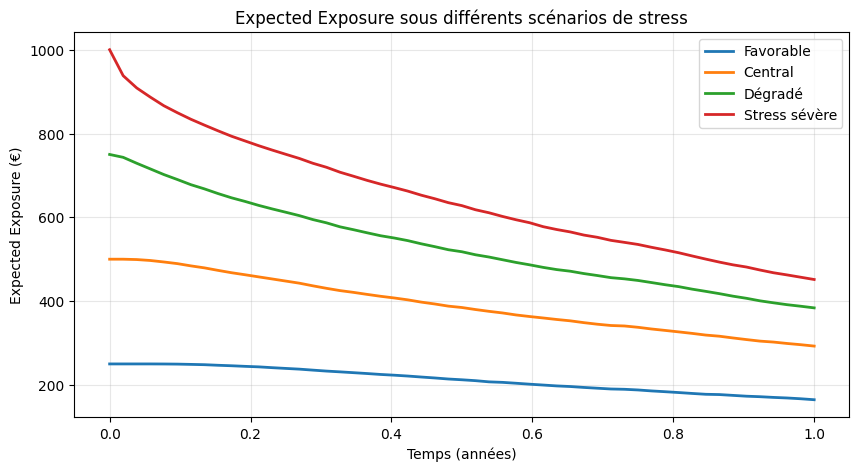

In [82]:
plt.figure(figsize=(10, 5))

for scenario_name, profiles in stress_profiles.items():

    plt.plot(
        times,
        profiles["EE"],
        linewidth=2,
        label=scenario_name
    )

plt.title(
    "Expected Exposure sous différents scénarios de stress"
)

plt.xlabel("Temps (années)")
plt.ylabel("Expected Exposure (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 7.6 Comparaison des PFE

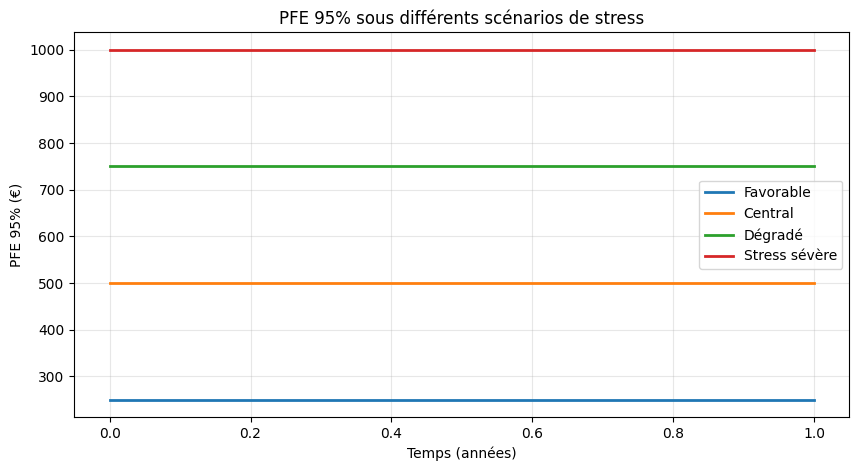

In [83]:
plt.figure(figsize=(10, 5))

for scenario_name, profiles in stress_profiles.items():

    plt.plot(
        times,
        profiles["PFE95"],
        linewidth=2,
        label=scenario_name
    )

plt.title(
    "PFE 95% sous différents scénarios de stress"
)

plt.xlabel("Temps (années)")
plt.ylabel("PFE 95% (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

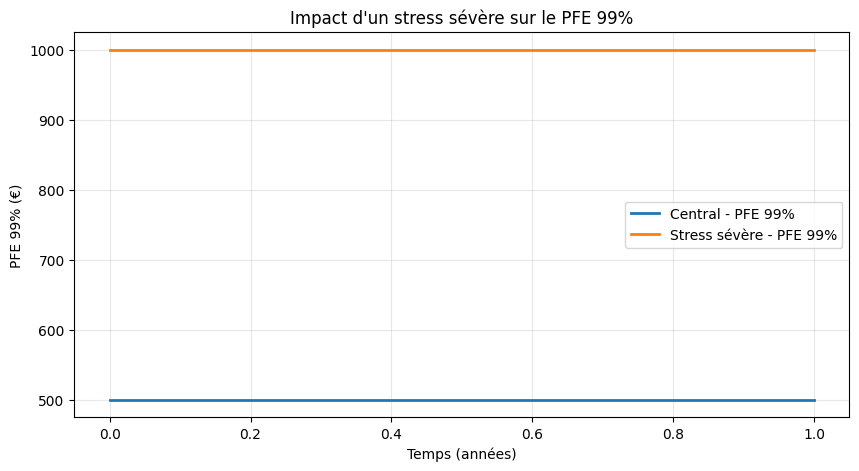

In [84]:
plt.figure(figsize=(10, 5))

plt.plot(
    times,
    stress_profiles["Central"]["PFE99"],
    linewidth=2,
    label="Central - PFE 99%"
)

plt.plot(
    times,
    stress_profiles["Stress sévère"]["PFE99"],
    linewidth=2,
    label="Stress sévère - PFE 99%"
)

plt.title(
    "Impact d'un stress sévère sur le PFE 99%"
)

plt.xlabel("Temps (années)")
plt.ylabel("PFE 99% (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 7.7 Comparaison des CVA

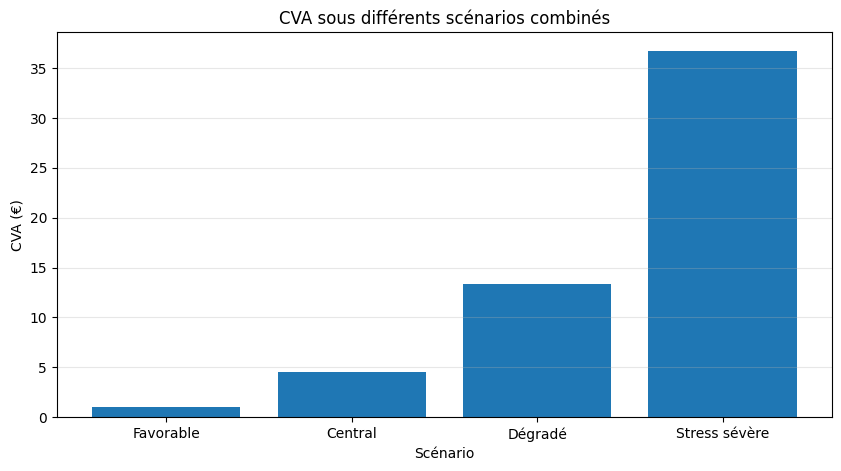

In [85]:
plt.figure(figsize=(10, 5))

plt.bar(
    stress_df["Scénario"],
    stress_df["CVA"]
)

plt.title(
    "CVA sous différents scénarios combinés"
)

plt.xlabel("Scénario")
plt.ylabel("CVA (€)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 7.8 Mesure de l’impact par rapport au scénario central

In [86]:
central_cva = stress_df.loc[
    stress_df["Scénario"] == "Central",
    "CVA"
].iloc[0]

stress_df["Variation CVA vs Central"] = (
    stress_df["CVA"]
    / central_cva
    - 1
)

stress_df[
    [
        "Scénario",
        "CVA",
        "Variation CVA vs Central"
    ]
].round(4)

,Scénario,CVA,Variation CVA vs Central
0,Favorable,1.0363,-0.7733
1,Central,4.5704,0.0000
2,Dégradé,13.3513,1.9213
3,Stress sévère,36.7492,7.0407


In [87]:
for _, row in stress_df.iterrows():

    print(
        f"{row['Scénario']:<15} : "
        f"CVA = {row['CVA']:,.2f} € | "
        f"Variation = "
        f"{row['Variation CVA vs Central']:.2%}"
    )

Favorable       : CVA = 1.04 € | Variation = -77.33%
Central         : CVA = 4.57 € | Variation = 0.00%
Dégradé         : CVA = 13.35 € | Variation = 192.13%
Stress sévère   : CVA = 36.75 € | Variation = 704.07%


### Interprétation des Stress Tests combinés

Les scénarios combinés montrent que le risque de contrepartie peut évoluer fortement lorsque plusieurs facteurs se détériorent simultanément.

Une hausse de la volatilité modifie la distribution des Mark-to-Market futurs et peut augmenter les expositions extrêmes.

Une augmentation du hazard rate accroît la probabilité de défaut de la contrepartie, tandis qu'une diminution du Recovery Rate augmente la perte supportée en cas de défaut.

Enfin, une augmentation du Threshold laisse une part plus importante de l'exposition non couverte par le collatéral.

La combinaison de ces facteurs peut conduire à une augmentation significative du PFE et de la CVA par rapport au scénario central.

Ces résultats illustrent l'intérêt des stress tests multi-facteurs dans l'analyse du risque de contrepartie.

### Remarque méthodologique

Les scénarios présentés ici sont des scénarios déterministes construits à des fins d'analyse et de validation.

Ils ne constituent pas des prévisions de marché.

Dans une application professionnelle, les scénarios de stress pourraient être définis à partir de chocs historiques, de scénarios réglementaires ou de scénarios internes calibrés sur les caractéristiques du portefeuille et de la contrepartie.

## 8. Limites du modèle et pistes d'amélioration

Le moteur développé dans ce projet permet d'illustrer les principales composantes du risque de contrepartie : simulation des facteurs de marché, revalorisation des produits dérivés, calcul des expositions futures, CVA, netting, collateral et stress testing.

Cependant, plusieurs hypothèses simplificatrices ont été retenues afin de conserver un cadre pédagogique et interprétable.

Cette section présente les principales limites du modèle ainsi que les améliorations qui pourraient être apportées dans une version plus avancée.

### 8.1 Volatilité constante

Le modèle de Black-Scholes suppose une volatilité constante pendant toute la durée de vie de l'option.

Dans les marchés financiers réels, la volatilité varie dans le temps et dépend notamment du strike et de la maturité.

Cette hypothèse pourrait être améliorée en utilisant :

- une surface de volatilité implicite ;
- un modèle de volatilité locale ;
- un modèle de volatilité stochastique tel que Heston.

Une modélisation plus réaliste de la volatilité permettrait d'améliorer la valorisation des produits dérivés et les profils d'exposition future.

### 8.2 Taux d'intérêt constant

Le moteur suppose également un taux sans risque constant sur l'horizon de simulation.

Cette hypothèse est adaptée à une première implémentation, mais elle devient restrictive pour les produits sensibles aux taux d'intérêt ou pour les maturités longues.

Une extension possible consisterait à simuler une courbe de taux dynamique à l'aide de modèles tels que :

- Vasicek ;
- Hull-White ;
- CIR.

Cela permettrait notamment d'étendre le moteur à des swaps de taux d'intérêt et à d'autres produits sensibles à la structure de la courbe des taux.

### 8.3 Hazard Rate constant

La probabilité de défaut de la contrepartie est modélisée à partir d'un hazard rate constant.

En pratique, le risque de crédit varie avec la maturité et les conditions de marché.

Une approche plus avancée consisterait à construire une courbe de hazard rates par maturité, éventuellement calibrée à partir de spreads de CDS ou d'autres instruments de crédit.

Cette amélioration permettrait d'obtenir une structure temporelle plus réaliste des probabilités de défaut.

### 8.4 Indépendance entre exposition et défaut

Le calcul de CVA utilisé dans ce projet suppose que l'exposition future et le défaut de la contrepartie sont indépendants.

Cette hypothèse peut être insuffisante lorsque la détérioration de la qualité de crédit de la contrepartie est liée à l'évolution des facteurs de marché.

Lorsque l'exposition augmente précisément dans les scénarios où la probabilité de défaut augmente, on parle de **Wrong-Way Risk**.

À l'inverse, lorsque l'exposition diminue lorsque le risque de défaut augmente, on parle de **Right-Way Risk**.

Une extension du moteur pourrait introduire une dépendance entre les facteurs de marché et le processus de défaut afin de modéliser explicitement le Wrong-Way Risk.

### 8.5 Modélisation simplifiée du collateral

Le mécanisme de collatéralisation utilisé dans ce projet suppose un transfert immédiat du collatéral lorsque le Threshold est dépassé.

Dans la pratique, la gestion du collateral dépend de nombreux paramètres supplémentaires :

- Minimum Transfer Amount (MTA) ;
- fréquence des appels de marge ;
- délai de règlement ;
- Margin Period of Risk ;
- Independent Amount ;
- type et qualité du collateral ;
- haircuts appliqués aux actifs remis en garantie.

Une modélisation plus complète de ces éléments permettrait d'obtenir une estimation plus réaliste de l'exposition résiduelle.

### 8.6 Univers de produits limité

Le portefeuille utilisé dans cette première version est composé principalement d'options européennes simples.

Cette approche permet de valider les mécanismes du moteur, mais ne représente pas toute la diversité des produits présents dans les portefeuilles de marché.

Le moteur pourrait être étendu à :

- swaps de taux d'intérêt ;
- forwards ;
- FX forwards ;
- options de change ;
- swaps de devises ;
- produits structurés ;
- dérivés exotiques.

Cette extension nécessiterait notamment des modèles de pricing et de simulation adaptés à plusieurs facteurs de marché.

### 8.7 Extensions vers les autres XVA

Le moteur calcule actuellement uniquement la Credit Valuation Adjustment (CVA).

Dans un cadre professionnel, la valorisation des dérivés peut également intégrer plusieurs ajustements complémentaires, regroupés sous le terme XVA.

Parmi les principales extensions possibles :

- **DVA (Debit Valuation Adjustment)** : ajustement lié au risque de défaut propre de l'institution ;
- **FVA (Funding Valuation Adjustment)** : coût de financement associé aux positions ;
- **MVA (Margin Valuation Adjustment)** : coût lié au financement des marges ;
- **KVA (Capital Valuation Adjustment)** : coût du capital réglementaire.

Une version avancée du projet pourrait ainsi évoluer vers un moteur XVA plus complet.

### 8.8 Risque de modèle

Les résultats obtenus dépendent directement des hypothèses et paramètres retenus.

Une mauvaise estimation de la volatilité, du hazard rate, du Recovery Rate ou des paramètres de collateral peut entraîner une mauvaise estimation des expositions et de la CVA.

La validation du modèle doit donc inclure :

- des tests de cohérence ;
- des analyses de sensibilité ;
- des stress tests ;
- des comparaisons avec des résultats analytiques lorsque cela est possible ;
- un suivi régulier des hypothèses et paramètres.

Les travaux réalisés dans ce notebook constituent une première démarche de validation quantitative du moteur.

## 9. Conclusion

Ce notebook a permis de compléter le Counterparty Credit Risk Engine par une démarche de validation quantitative et de stress testing.

Les principaux composants du moteur ont été analysés et testés :

- validation du pricing Black-Scholes ;
- convergence des simulations Monte Carlo ;
- comparaison du pricing Monte Carlo avec la solution analytique ;
- analyse de la stabilité des métriques EE et PFE ;
- validation de la sensibilité de la CVA au hazard rate, au Recovery Rate et au niveau d'exposition ;
- validation de l'impact du netting et du collateral ;
- analyse de scénarios combinés de marché et de crédit.

Les résultats montrent que le moteur réagit de manière cohérente aux principaux facteurs de risque et aux mécanismes de réduction de l'exposition.

Cette version constitue une base quantitative solide pour l'analyse du risque de contrepartie, tout en laissant plusieurs pistes d'amélioration vers une modélisation plus réaliste du Wrong-Way Risk, des courbes de taux, du collateral et des autres ajustements XVA.

### Architecture validée du moteur

**Market Factors**  
↓  
**Monte Carlo Simulation**  
↓  
**Derivative Pricing**  
↓  
**Future Mark-to-Market**  
↓  
**Exposure Profiles**  
↓  
**EE / EPE / PFE**  
↓  
**Default Probabilities**  
↓  
**CVA**  
↓  
**Netting & Collateral**  
↓  
**Stress Testing & Model Validation**